In [2]:
from ESRNN.utils_evaluation import evaluate_prediction_owa
from ESRNN import ESRNN
from ESRNN.utils_evaluation import Naive2, Naive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pickle


In [4]:
df = pd.read_csv(
    "/home/erti/PROJECT_repos/ForeST_HPO/hpo-innosuisse/data/2024-05-27 DE Auftragseingang Maschinenbau 28.00.csv"
)
df.columns

Index(['Datum', 'Insgesamt', 'Inland', 'Ausland', 'Ausland (Eurozone)',
       'Ausland (Nicht-Eurozone)'],
      dtype='object')

In [5]:
y_df = pd.DataFrame()
y_df["ds"] = pd.to_datetime(df["Datum"])
y_df["y"] = df["Insgesamt"]
y_df["unique_id"] = "Insgesamt"


In [6]:
assert y_df.isna().sum().sum() == 0, "There are NaN values in the data"

In [7]:
x_df = y_df.drop("y", 1)
x_df["x"] = "Macro"  # TODO

In [8]:
SPLIT_IDX = y_df[y_df.ds == pd.to_datetime("2017-01-31")].index[0]
print(SPLIT_IDX, SPLIT_IDX / len(y_df))

y_train_df = y_df.iloc[:SPLIT_IDX]
y_test_df = y_df.iloc[SPLIT_IDX:]

X_train_df = x_df.iloc[:SPLIT_IDX]
X_test_df = x_df.iloc[SPLIT_IDX:]

312 0.7819548872180451


In [9]:
# naive = Naive() # TODO use Naive2 or SesonalNaive
# naive.fit(y_test_df)

y_test_df["y_hat_naive2"] = y_test_df["y"].shift(1).fillna(method="bfill")

/tmp/nix-shell-81580-0/ipykernel_97013/1444109779.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test_df["y_hat_naive2"] = y_test_df["y"].shift(1).fillna(method="bfill")


In [ ]:
# Instantiate model

INPUT_SIZE = 4
OUTPUT_SIZE = 6

model = ESRNN(
    max_epochs=25,
    freq_of_test=5,
    batch_size=1,  # assert self.batch_size <= self.n_series
    learning_rate=1e-4,
    per_series_lr_multip=0.8,
    lr_scheduler_step_size=10,
    lr_decay=0.1,
    gradient_clipping_threshold=50,
    rnn_weight_decay=0.0,
    level_variability_penalty=100,
    testing_percentile=50,
    training_percentile=50,
    ensemble=False,
    max_periods=25,
    seasonality=[],
    input_size=INPUT_SIZE,
    output_size=OUTPUT_SIZE,
    cell_type="LSTM",
    state_hsize=40,
    dilations=[[1], [6]],
    add_nl_layer=False,
    random_seed=1,
    device="cuda",  # FIXED ERTI
)

In [ ]:
# with open("forest_model.pkl", "rb") as f:
#     model = pickle.load(f)

In [ ]:
# Fit model
# If y_test_df is provided the model will evaluate predictions on this set every freq_test epochs


model.fit(
    X_train_df,
    y_train_df,
    X_test_df,
    y_test_df,
)

with open("forest_model.pkl", "wb") as f:
    pickle.dump(model, f)


In [ ]:
# Predict on test set
# HINT is only a "local" model. Can only predict contiguous to training and needs to be retrained
i = 0
y_hat_df = model.predict(X_test_df[i:i+OUTPUT_SIZE])

# Evaluate predictions
final_owa, final_mase, final_smape = evaluate_prediction_owa(
    y_hat_df,
    # y_train_df,
    y_df[:SPLIT_IDX+i],
    X_test_df[i:i+OUTPUT_SIZE],
    y_test_df[i:i+OUTPUT_SIZE],
    naive2_seasonality=1,
)

===============  Model evaluation  ==============
OWA: 0.966 
SMAPE: 7.683 
MASE: 1.528 


/home/erti/PROJECT_repos/ForeST_HPO/ES_RNN_Smyl_M4/esrnn_torch/.venv/lib/python3.9/site-packages/torch/nn/modules/rnn.py:1124: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at /pytorch/aten/src/ATen/native/cudnn/RNN.cpp:1412.)
  result = _VF.lstm(


M4 Parameters:

    OWA: 0.966 
    SMAPE: 7.683 
    MASE: 1.528 



In [64]:
y_hat_df.head(10)

,ds,unique_id,x,y_hat
0,2017-01-31,Insgesamt,Macro,117.825272
1,2017-02-28,Insgesamt,Macro,118.034561
2,2017-03-31,Insgesamt,Macro,114.321899
3,2017-04-30,Insgesamt,Macro,104.036354
4,2017-05-31,Insgesamt,Macro,112.696999
5,2017-06-30,Insgesamt,Macro,119.210953
6,2017-07-31,Insgesamt,Macro,NaN
7,2017-08-31,Insgesamt,Macro,NaN
8,2017-09-30,Insgesamt,Macro,NaN
9,2017-10-31,Insgesamt,Macro,NaN


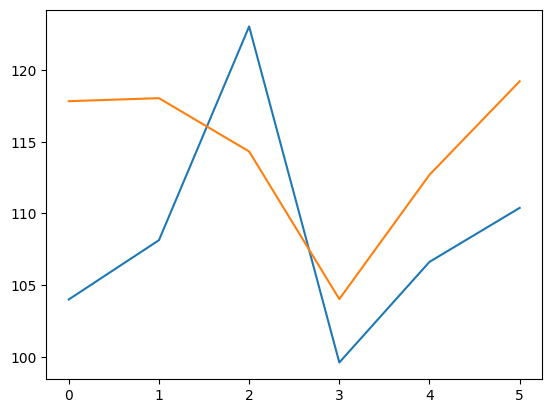

In [15]:
plt.plot(y_test_df[:6].y.values, label="y")
plt.plot(y_hat_df[:6].y_hat.values, label="y_hat")

In [ ]:
preds = []

for i in range(0,len(y_test_df)-6):
    

In [ ]:
# y_hat_df["y_test"] = y_test_df["y"]

In [ ]:
# y_hat_df.to_csv("y_hat_df.csv")